# Forecasting with ARIMA
- We use 'Tractor-Sales.csv' dataset
- We implement ARIMA models to forecast sales
- Refereence: http://ucanalytics.com/blogs/wp-content/uploads/2017/08/ARIMA-TimeSeries-Analysis-of-Tractor-Sales.html

In [ ]:
#mount google drive to read data
dataFile = 'Tractor-Sales.csv'

import pandas as pd
from google.colab import data_table
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/DSBA6211_DATA/'+ dataFile
df = pd.read_csv(path,sep=",",)
drive.flush_and_unmount()

df.describe(include='all').T

Mounted at /content/drive


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,144,144,1/1/2003,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales,144.0,NaN,NaN,NaN,389.694444,171.500016,138.0,248.5,369.0,509.25,871.0


In [ ]:
# Check the data types and display the first 5 and last 5 rows of the dataframe
print(df.dtypes)
print(df.head())
print(df.tail())

Date     object
Sales     int64
dtype: object
       Date  Sales
0  1/1/2003    141
1  2/1/2003    157
2  3/1/2003    185
3  4/1/2003    199
4  5/1/2003    203
          Date  Sales
139   8/1/2014    848
140   9/1/2014    640
141  10/1/2014    581
142  11/1/2014    519
143  12/1/2014    605


In [ ]:
# Convert data to time series
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
sales_ts = pd.Series(df['Sales'].values, index=df['Date'], name='Sales')

In [ ]:
# Display the time series data
sales_ts

,Sales
Date,
2003-01-01,141
2003-02-01,157
2003-03-01,185
2003-04-01,199
2003-05-01,203
...,...
2014-08-01,848
2014-09-01,640
2014-10-01,581


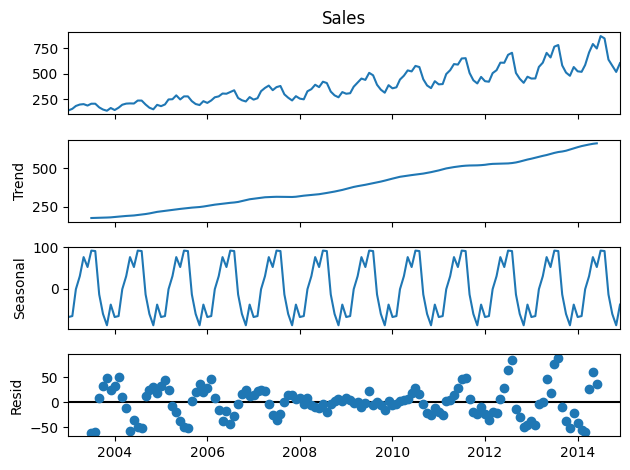

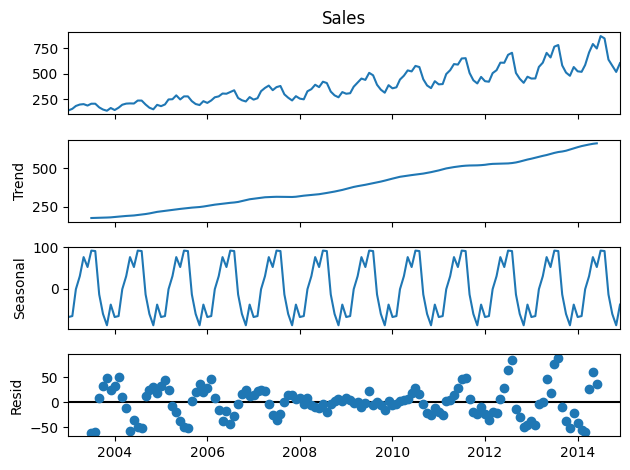

In [ ]:
# Have a look at the time series. How does it look when it is decomposed?
from statsmodels.tsa.seasonal import seasonal_decompose
sd = seasonal_decompose(sales_ts,model='additive',period=12)
sd.plot()

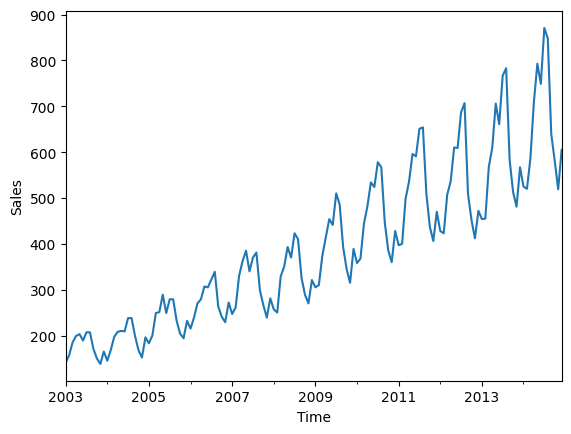

In [ ]:
# Plot the time series
# Is this time series stationary?
import matplotlib.pylab as plt
ax = sales_ts.plot()
ax.set_xlabel('Time')
ax.set_ylabel('Sales')
plt.show()


In [ ]:
# Dickey-Fuller Test to verify whether a time-series is stationary
# p-vlaue: insignificance indicating non-stationary
# Test Statistic > Critical Value: non-stationary

from statsmodels.tsa.stattools import adfuller
print('Results of Dickey-Fuller Test:')
dftest = adfuller(sales_ts,autolag='AIC')
dfoutput = pd.Series(dftest[0:4],index=['Test Statistic', 'p-value', '#lags used', 'Number of observations Used'])

for key , value in dftest[4].items(): dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)


Results of Dickey-Fuller Test:
Test Statistic                   1.108825
p-value                          0.995291
#lags used                      14.000000
Number of observations Used    129.000000
Critical Value (1%)             -3.482088
Critical Value (5%)             -2.884219
Critical Value (10%)            -2.578864
dtype: float64


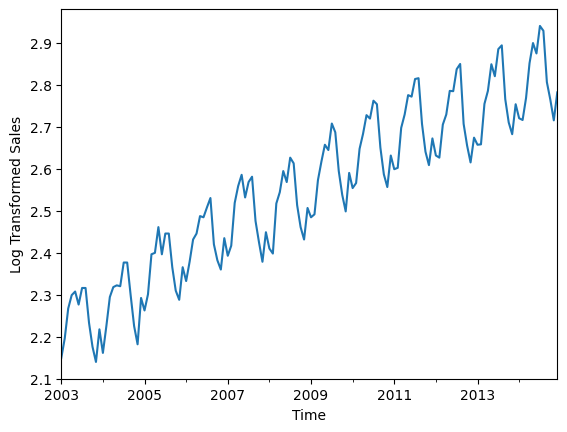

In [ ]:
# Log transformation to achieve constant variance
import numpy as np
sales_ts_log = np.log10(sales_ts)
ax = sales_ts_log.plot()
ax.set_xlabel('Time')
ax.set_ylabel('Log Transformed Sales')
plt.show()

In [ ]:
# Dickey-Fuller Test on log-transformed series
print('Results of Dickey-Fuller Test on log-transformed series:')
dftest_log = adfuller(sales_ts_log,autolag='AIC')
dfoutput_log = pd.Series(dftest_log[0:4],index=['Test Statistic', 'p-value', '#lags used', 'Number of observations Used'])

for key , value in dftest_log[4].items(): dfoutput_log['Critical Value (%s)'%key] = value
print(dfoutput_log)

Results of Dickey-Fuller Test on log-transformed series:
Test Statistic                  -1.732472
p-value                          0.414464
#lags used                      13.000000
Number of observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


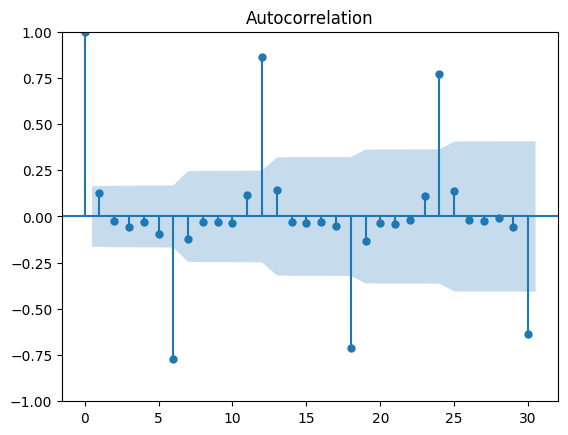

In [ ]:
# Plot ACF to check potential seasonality
# ACF: autocorrelation factor
import statsmodels.tsa.api as smt
sales_ts_log_diff = sales_ts_log.diff(periods= 1)
sales_ts_log_diff.dropna(inplace=True)
smt.graphics.plot_acf(sales_ts_log_diff, lags=30, alpha= 0.05)
plt.show()

In [ ]:
# Data partition for the time series data
# Keep the last three years data as the validation dataset
nValid = 36
nTrain = len(sales_ts_log) - nValid
train_ts = sales_ts_log[:nTrain]
valid_ts = sales_ts_log[nTrain:]

In [ ]:
# Display the training dataset
train_ts

,Sales
Date,
2003-01-01,2.149219
2003-02-01,2.195900
2003-03-01,2.267172
2003-04-01,2.298853
2003-05-01,2.307496
...,...
2011-08-01,2.815578
2011-09-01,2.706718
2011-10-01,2.640481


In [ ]:
# To identify the best fit ARIMA model
import itertools
# Define the p, d and q parameters to take any value between 0 and 2
p = d = q = range(0,3)
# Generate all possible combinations of p, d and q triplets
pdq = list(itertools.product(p, d, q))
# Generate all possible combinations of seasonal p, d and q triplets
seasonal_pdq = [(x[0],x[1],x[2],12) for x in list(itertools.product(p, d, q))]
# Display p, d and q combinations
pdq


[(0, 0, 0),
 (0, 0, 1),
 (0, 0, 2),
 (0, 1, 0),
 (0, 1, 1),
 (0, 1, 2),
 (0, 2, 0),
 (0, 2, 1),
 (0, 2, 2),
 (1, 0, 0),
 (1, 0, 1),
 (1, 0, 2),
 (1, 1, 0),
 (1, 1, 1),
 (1, 1, 2),
 (1, 2, 0),
 (1, 2, 1),
 (1, 2, 2),
 (2, 0, 0),
 (2, 0, 1),
 (2, 0, 2),
 (2, 1, 0),
 (2, 1, 1),
 (2, 1, 2),
 (2, 2, 0),
 (2, 2, 1),
 (2, 2, 2)]

In [ ]:
# Display seasonal  P, D and Q combinations
seasonal_pdq

[(0, 0, 0, 12),
 (0, 0, 1, 12),
 (0, 0, 2, 12),
 (0, 1, 0, 12),
 (0, 1, 1, 12),
 (0, 1, 2, 12),
 (0, 2, 0, 12),
 (0, 2, 1, 12),
 (0, 2, 2, 12),
 (1, 0, 0, 12),
 (1, 0, 1, 12),
 (1, 0, 2, 12),
 (1, 1, 0, 12),
 (1, 1, 1, 12),
 (1, 1, 2, 12),
 (1, 2, 0, 12),
 (1, 2, 1, 12),
 (1, 2, 2, 12),
 (2, 0, 0, 12),
 (2, 0, 1, 12),
 (2, 0, 2, 12),
 (2, 1, 0, 12),
 (2, 1, 1, 12),
 (2, 1, 2, 12),
 (2, 2, 0, 12),
 (2, 2, 1, 12),
 (2, 2, 2, 12)]

In [ ]:
# Set up the initial values
best_aic = np.inf
best_pdq = None
best_seasonal_pdq = None
temp_model = None



In [ ]:
import sys
# Specify to ignore warning messages
import warnings
warnings.filterwarnings("ignore")

import statsmodels.api as sm
# Using loops to search for the best ARIMA model
# Choose the best ARIMA model based on minimum AIC values
# AIC: to balance the model between goodness-of-fit and number of parameters
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            temp_model = sm.tsa.statespace.SARIMAX(train_ts,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=True,
                                            enforce_invertibility=True)
            results = temp_model.fit()

            if results.aic < best_aic:
                best_aic = results.aic
                best_pdq = param
                best_seasonal_pdq = param_seasonal

        except:
            continue
    print("Best SARIMAX{}x{}12 model - AIC:{}".format(best_pdq, best_seasonal_pdq, best_aic))

Best SARIMAX(0, 0, 0)x(1, 1, 2, 12)12 model - AIC:-381.3122595644038
Best SARIMAX(0, 0, 1)x(1, 1, 2, 12)12 model - AIC:-417.54649834430165
Best SARIMAX(0, 0, 2)x(1, 1, 2, 12)12 model - AIC:-443.01050496271716
Best SARIMAX(0, 1, 0)x(1, 0, 1, 12)12 model - AIC:-527.8968466606786
Best SARIMAX(0, 1, 1)x(1, 0, 1, 12)12 model - AIC:-535.2434784874567
Best SARIMAX(0, 1, 1)x(1, 0, 1, 12)12 model - AIC:-535.2434784874567
Best SARIMAX(0, 1, 1)x(1, 0, 1, 12)12 model - AIC:-535.2434784874567
Best SARIMAX(0, 1, 1)x(1, 0, 1, 12)12 model - AIC:-535.2434784874567
Best SARIMAX(0, 1, 1)x(1, 0, 1, 12)12 model - AIC:-535.2434784874567
Best SARIMAX(0, 1, 1)x(1, 0, 1, 12)12 model - AIC:-535.2434784874567
Best SARIMAX(0, 1, 1)x(1, 0, 1, 12)12 model - AIC:-535.2434784874567
Best SARIMAX(0, 1, 1)x(1, 0, 1, 12)12 model - AIC:-535.2434784874567
Best SARIMAX(0, 1, 1)x(1, 0, 1, 12)12 model - AIC:-535.2434784874567
Best SARIMAX(0, 1, 1)x(1, 0, 1, 12)12 model - AIC:-535.2434784874567
Best SARIMAX(0, 1, 1)x(1, 0, 1, 

In [ ]:
# Display best ARIMA model detailed results
best_model = sm.tsa.statespace.SARIMAX(train_ts,
                                       order=(0,1,1),
                                       seasonal_order=(1,0,1,12),
                                       enforce_stationarity=True,
enforce_invertibility=True)

best_results = best_model.fit()

In [ ]:
# Display coefficients for the AR & MA components
# sigma square: variance of residuals
print(best_results.summary().tables[0])
print(best_results.summary().tables[1])

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                  108
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 12)   Log Likelihood                 271.622
Date:                            Tue, 04 Nov 2025   AIC                           -535.243
Time:                                    21:48:57   BIC                           -524.552
Sample:                                01-01-2003   HQIC                          -530.909
                                     - 12-01-2011                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3225      0.085     -3.804      0.000      -0.489      -0.156
ar.S.L12       0.9933      0.006   

In [ ]:
# Forecast sales using the best ARIMA model
# alpha=0.05, 95% confidence intervals
pred = best_results.get_forecast(steps=36,alpha=0.05)
# Evaluate the best ARIMA model performance
! pip install dmba
from dmba import regressionSummary
regressionSummary(np.power(10,valid_ts),
                  np.power(10,pred.predicted_mean))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 105.7 MB/s eta 0:00:00
Colab environment detected.

Regression statistics

                      Mean Error (ME) : -39.2165
       Root Mean Squared Error (RMSE) : 43.5992
            Mean Absolute Error (MAE) : 39.3865
          Mean Percentage Error (MPE) : -6.9441
Mean Absolute Percentage Error (MAPE) : 6.9681
